## Vanilla DDM: fitting empirical data

DDM with drift rate, starting point, boundary, and non-decision time. No across-trial variability parameters.

Drift rate is multiplied with stimulus (uniform between -1 or +1)

Starting point is drawn on unbounded scale, and then sigmoid transformed to constrain between 0 and 1 (relative to boundary separation)

In [1]:
import numpy as np
import os
from numba import njit
import bayesflow as bf
import tensorflow as tf
from scipy.stats import uniform, pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32

import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)
from tensorflow.python.platform import build_info as tf_build_info
print("cudnn_version",tf_build_info.build_info['cudnn_version'])
print("cuda_version",tf_build_info.build_info['cuda_version'])

2026-06-30 10:22:04.540845: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-30 10:22:04.540880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-30 10:22:04.542352: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-30 10:22:04.549610: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-06-30 10:22:06.059899: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


cudnn_version 8
cuda_version 12.2


In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Create folder if it does not exist
os.makedirs("Figures", exist_ok=True)
os.makedirs("Data", exist_ok=True)

In [4]:
dataset = 'Maniscalco_2017_expt2'

## Set priors

In [5]:
RNG = np.random.default_rng(0)

min_n_trials = 350
max_n_trials = 3250

batch_size = 32

"""
Set parameters for prior distributions 
"""

# uniform for drift rate, starting point, boundary, and non-decision time
v_lower, v_upper = 0.0, 5.0
z_lower, z_upper = -2.0, 2.0
a_lower, a_upper = 0.1, 5.0
ter_lower, ter_upper = 0.01, 1.0

## Prior functions

In [6]:
def sample_shared_parameters():
    """
    Drift rate, starting point, boundary, non-decision time
    """
    
    v = np.random.uniform(v_lower, v_upper) # drift rate
    z = np.random.uniform(z_lower, z_upper) # starting point (relative to boundary), before sigmoid transformation
    a = np.random.uniform(a_lower, a_upper) # boundary
    ter = np.random.uniform(ter_lower, ter_upper) # non-decision time
    
    shared_parameters = np.concatenate([np.r_[v, z, a, ter]])
    
    return shared_parameters
    

## Sample diffusion trial

In [7]:
@cuda.jit
def _sample_one_diffusion_trial(rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, num_threads):
    """
    Generates a single response time from a Diffusion Decision process.
    """
    
    thread_id = cuda.grid(1)
    
    if (thread_id < num_threads):
        
        # Input parameters
        v = in_v[thread_id]
        z = in_z[thread_id]
        a = in_a[thread_id]
        ter = in_ter[thread_id]
        
        # Simulation parameters
        dt=0.005             # time resolution of process, 5 milliseconds
        max_iter=int(5/dt)   # max iterations of the process, 5 seconds (1000 iterations)
        s=1.0                # scaling factor of the Wiener noise
        c = (dt * s)**0.5    # np.sqrt does not work with cuda.jit  
        
        # Initialize
        transformed_z = 1/(1+math.exp(-z)) # constrain z between 0 and 1 with sigmoid transformation
        evidence = a * (transformed_z)     # initialize first value (starting point plus bias relative to boundary)
        slope_dt = v*dt
        n_iter = 0
        
        # Diffusion process
        while evidence > 0 and evidence < a and n_iter < max_iter:
            n_iter += 1
            evidence += slope_dt + c * xoroshiro128p_normal_float32(rng_states, thread_id)

        # Determine response
        rt = n_iter * dt + ter
        
        if evidence >= a:
            resp =  1
        elif evidence <= 0:
            resp = 0
            
        out_rt[thread_id] = rt
        out_resp[thread_id] = resp

## Cuda helper functions

In [8]:
@njit(fastmath=True)
def cuda_convert_parameters(shared_parameters, condition_matrix, num_trials):
    """
    Convert the batched parameters into a vector for each parameter separately (needed for GPU threads)
    """
    
    batch_size = shared_parameters.shape[0]

    in_v = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_ter = np.zeros(batch_size * num_trials, dtype=np.float32)

    for dataset in range(batch_size): # loop over datasets
    
        shared_parameters_subset = shared_parameters[dataset]
        condition_matrix_subset = condition_matrix[dataset]
        
        for trial in range(num_trials): # loop over trials
                
            in_index = dataset * num_trials + trial

            in_v[in_index] = shared_parameters_subset[0] * condition_matrix_subset[trial] # multiply drift rate with stimulus
            in_z[in_index] = shared_parameters_subset[1]
            in_a[in_index] = shared_parameters_subset[2]
            in_ter[in_index] = shared_parameters_subset[3]

    return in_v, in_z, in_a, in_ter


@njit(fastmath=True)
def cuda_convert_sim_data(shared_parameters, condition_matrix, num_trials, out_rt, out_resp):
    """
    Convert GPU thread output back to Bayesflow format
    """
    
    batch_size = shared_parameters.shape[0]

    out = np.zeros((batch_size, num_trials, 2), dtype=np.float32) # rt, resp

    for dataset in range(batch_size): # loop over datasets
        for trial in range(num_trials): # loop over trials

            # simulated data as a 3D tensor of shape (num_datasets, num_trials, num_variables)
            out_index = dataset * num_trials + trial
            out[dataset, trial, :] = np.array([out_rt[out_index], out_resp[out_index]], dtype=np.float32)

    return out

## Sample multiple diffusion trials

In [9]:
#  in addition to the vector of parameters, our simulator takes the design matrix (i.e., batchable context) 
# and the number of observations (i.e., non-batchable context) as arguments
def sample_multiple_diffusion_trials(shared_parameters, condition_matrix, num_trials):
    """
    Generates DDM data for one participants with N trials
    """

    batch_size = shared_parameters.shape[0]
    
    threads_per_block = 32
    total_threads = int(batch_size * num_trials)
    blocks = math.ceil(total_threads / threads_per_block)
    
    rng_states = create_xoroshiro128p_states(total_threads, seed=0)
    
    in_v, in_z, in_a, in_ter = cuda_convert_parameters(shared_parameters, condition_matrix, num_trials)    
    
    # one iteration happens fully in parallel (so each trial for all datasets in parallel)
    out_rt = np.zeros(batch_size * num_trials, dtype=np.float32)
    out_resp = np.zeros(batch_size * num_trials, dtype=np.float32)
    
    # KEY LINE: each GPU thread will compute one DDM trial!
    _sample_one_diffusion_trial[blocks, threads_per_block](rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, total_threads)

    out = cuda_convert_sim_data(shared_parameters, condition_matrix, num_trials, out_rt, out_resp)
    
    return out

## Helper functions

In [10]:
def return_mean_std_shared_parameters():
    """
    Return the mean and standard deviation of shared parameters
    """
    
    v_mean, v_std = uniform.stats(v_lower, v_upper, moments='mv')
    z_mean, z_std = uniform.stats(z_lower, z_upper, moments='mv')
    a_mean, a_std =  uniform.stats(a_lower, a_upper, moments='mv')
    ter_mean, ter_std =  uniform.stats(ter_lower, ter_upper, moments='mv')
    
    mean_shared = np.array([v_mean, z_mean, a_mean, ter_mean])
    std_shared = np.array([v_std, z_std, a_std, ter_std])
    
    return mean_shared, std_shared


In [11]:
def sample_n_trials(min_n_trials=min_n_trials, max_n_trials=max_n_trials):
    """
    Samples the number of trials used for all simulations in one batch.
    """
    
    num_trials = np.random.randint(min_n_trials, max_n_trials+1)
    
    return num_trials



def generate_condition_matrix(num_trials):
    """
    Draws a random design matrix (stimulus: either -1 or +1 on each trial) for each simulation in a batch.
    """

    condition_matrix = np.random.uniform(-1, 1, size=num_trials)
    
    return condition_matrix


## Setting up generator

In [12]:
prior = bf.simulation.Prior(prior_fun=sample_shared_parameters) 

experimental_context = bf.simulation.ContextGenerator(non_batchable_context_fun=sample_n_trials,
                                                      batchable_context_fun=generate_condition_matrix,
                                                      use_non_batchable_for_batchable=True)

simulator = bf.simulation.Simulator(batch_simulator_fun=sample_multiple_diffusion_trials,
                                    context_generator=experimental_context)

generative_model = bf.simulation.GenerativeModel(prior=prior, 
                                                 simulator=simulator) 

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 116 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/cuda/core/experimental/_linker.py:189: RuntimeWarning: nvJitLink is not installed or too old (<12.3). Therefore it is not usable and the culink APIs will be used instead.
  _lazy_init()
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


INFO:root:Performing 2 pilot runs with the anonymous model...


INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 4)


INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 1855, 2)


INFO:root:No optional prior non-batchable context provided.


INFO:root:No optional prior batchable context provided.


INFO:root:Could not determine shape of simulation non-batchable context. Type appears to be non-array: <class 'int'>,                                    so make sure your input configurator takes cares of that!


INFO:root:Could not determine shape of simulation batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes cares of that!


## Setting up amortizer

In [13]:
""" 
summary_net: 
    learns the most informative summary stats from data 
inference_net: 
    from summary statistics to posterior distributions - joint posterior distribution
amortizer: 
    connects the two networks
"""


summary_net = bf.networks.SetTransformer(input_dim=3, summary_dim=32) # input_dim: rt, response, stimulus
inference_net = bf.networks.InvertibleNetwork(num_params=4)
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

2026-06-30 10:22:16.391330: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15507 MB memory:  -> device: 0, name: Tesla P100-SXM2-16GB, pci bus id: 0000:89:00.0, compute capability: 6.0


## Checkpoint path

In [14]:
checkpoint_path = f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/1. Vanilla DDM/training_vanilla_ddm"
if not os.path.exists(checkpoint_path):
    os.makedirs(checkpoint_path)

## Create configurator

In [15]:

"""
takes the raw outputs of the generative models and turns them into something with which neural networks can work
"""


def configurator(raw_dict, transform=True):
        """Configures the output of self.generator for a BayesFlow pipeline.

        1. Converts float64 to float32 (for TensorFlow)
        2. Scale the model parameters if tranform=True

        Parameters:
        -----------
        raw_dict  : dict
            A simulation dictionary as returned by ``bayesflow.simulation.GenerativeModel``
        transform : boolean, optional, default: True
            An indicator to standardize the parameter and log-transform reaction times. 

        Returns:
        --------
        input_dict : dict
            The simulation dictionary configured for ``bayesflow.amortizers.Amortizer``
        """

        # Convert to float32
        shared_parameters = raw_dict.get("prior_draws").astype(np.float32)

        # Convert list of condition indicators to a 2D array and add a
        # trailing dimension of 1, so shape becomes (batch_size, num_obs, 1)
        # We need this in order to easily concatenate the context (condition matrix) with the data
        context = np.array(raw_dict["sim_batchable_context"])[..., None]
        data = raw_dict.get("sim_data").astype(np.float32) # [batch_size, num_trials, 2], last dimension is (rt, resp)

        # Concatenate data (rt, resp) and context (condition matrix)
        summary_conditions = np.c_[data, context].astype(np.float32)

        # Make inference network aware of varying numbers of trials
        # We create a vector of shape (batch_size, 1) by repeating the sqrt(num_trials)
        # num_trials calculated as the length of the condition matrix
        vec_num_trials = context.shape[1] * np.ones((data.shape[0], 1))
        direct_conditions = np.sqrt(vec_num_trials).astype(np.float32)

        if transform:
            mean_shared, std_shared = return_mean_std_shared_parameters()
            
            # Log transform reaction times
            summary_conditions[:,:,0] = np.log(summary_conditions[:,:,0])
            
            out_dict = dict(
                parameters=(shared_parameters-mean_shared.astype(np.float32))/std_shared.astype(np.float32),
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions # see https://bayesflow.org/_examples/LCA_Model_Posterior_Estimation.html#defining-the-configurator
            )
            
        else:
            out_dict = dict(
                parameters=shared_parameters,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions
            )

        return out_dict


## Loading in trained model

In [16]:
"""
Connect the networks (summary and inference) with the generative model 
"""


trainer = bf.trainers.Trainer(
    amortizer=amortizer,
    generative_model=generative_model,
    configurator=configurator,
    checkpoint_path=checkpoint_path)


INFO:root:Loaded loss history from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/1. Vanilla DDM/training_vanilla_ddm/history_500.pkl.


INFO:root:Networks loaded from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/1. Vanilla DDM/training_vanilla_ddm/ckpt-500


INFO:root:Performing a consistency check with provided components...


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


INFO:root:Done.


## Fitting empirical data

### 1. Creating correct data structure

In [17]:
# Load in data
data = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/Empirical data/{dataset}.csv")

# RT cleaning
data = data[(data['rt'] >= 0.1) & (data['rt'] <= 3)]

# Get number of trials per subject
unique_ids, counts = np.unique(data['subj'], return_counts=True)
print(counts)

num_subjects = len(unique_ids)
max_trials = np.max(counts)

# Change subject numbering starting from 0 uninterupted to num_subjects 
data['subj'] = np.repeat(np.arange(0,num_subjects), counts)


num_inputs = 3  # rt, response, signed_stim_diff

# Fill with NaNs for padding
df = np.full((num_subjects, max_trials, num_inputs), np.nan)

# Mask indicating valid trials (array of Falses)
trial_mask = np.zeros((num_subjects, max_trials), dtype=bool) 

for subj in range(num_subjects):

    temp = data[data.subj == subj]
    n_trials = len(temp)

    subj_data = np.vstack([temp.rt,
                           temp.resp,
                           temp.evidence]).T

    # Insert trials
    df[subj, :n_trials, :] = subj_data

    # Mark valid trials
    trial_mask[subj, :n_trials] = True

# Log-transform RTs only for valid trials
df[:, :, 0] = np.where(trial_mask,
                       np.log(df[:, :, 0]),
                       np.nan)

# Create context variable (for later)
context = df[:, :, 2]

[509 456 509 509 504 509 508 509 490 508 503 509 499 508 509 508 509 509
 505 509 509 509 507 509 508 497 509 507 509 487 509 505 508 507 500 509
 505 506 509 508 500]


### 2. Estimating parameters

In [18]:
# Fit model to empirical data
num_posterior_samples = 50
num_shared_parameters = 4

estimated_shared = np.zeros((num_subjects, num_posterior_samples, num_shared_parameters))

mean_shared, std_shared = return_mean_std_shared_parameters()

for subj in range(num_subjects):

    # Select only valid trials
    valid_idx = trial_mask[subj]
    subj_data = df[subj, valid_idx]

    n_trials = subj_data.shape[0]

    input_dict = {
        "summary_conditions": subj_data.reshape(1, n_trials, 3).astype(np.float32),
        "direct_conditions": np.array([[np.sqrt(n_trials)]], dtype=np.float32)
    }
    
    posterior_samples = amortizer.sample(
        input_dict,
        n_samples=num_posterior_samples
    )

    # Unstandardize posterior samples
    estimated_shared[subj] = (posterior_samples * std_shared + mean_shared)
    
# Posterior means
estimated_shared_mean = estimated_shared.mean(axis=1)

# Posterior stds
estimated_shared_std = estimated_shared.std(axis=1)

### 3. Plotting shared parameters

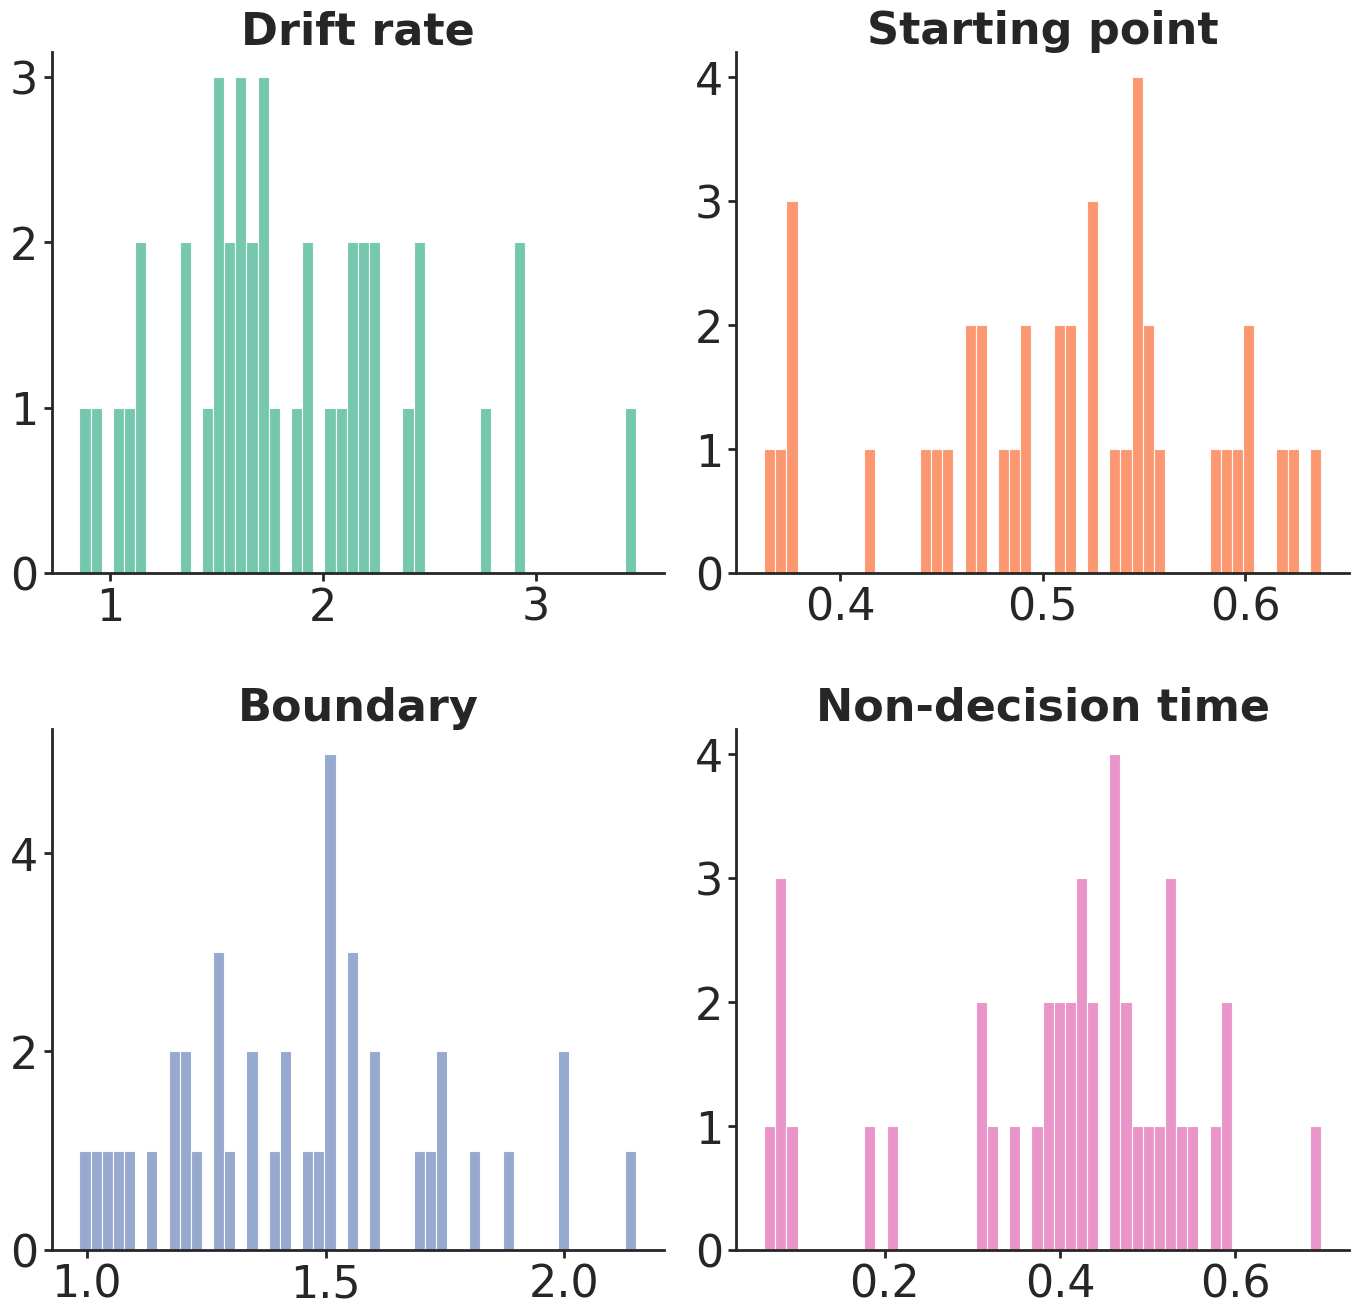

In [19]:
fontsize = 32

sns.set_theme(
    style="ticks",
    context="talk"
)

#shared_param_labels = ["Drift rate $v$", "Starting point $z$", "Boundary $a$", "Non-decision time $T_{er}$"]
shared_param_labels = ["Drift rate", "Starting point", "Boundary", "Non-decision time"]

# Set seaborn style
sns.set(style="ticks", font_scale=1.7)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for i, ax in enumerate(axes.flatten()):
    if i < len(shared_param_labels):
        
        if i == 1:
            values = 1 / (1 + np.exp(-estimated_shared_mean[:, i]))  # sigmoid transform
        else:
            values = estimated_shared_mean[:, i]

        ax.hist(values, bins=50, color=sns.color_palette("Set2")[i], edgecolor="white", linewidth=0.8, alpha=0.9)

        #ax.set_xlabel("Value", fontsize=fontsize)
        #ax.set_ylabel("Frequency", fontsize=fontsize)
        ax.set_title(shared_param_labels[i], fontsize=fontsize, fontweight='bold')
        ax.tick_params(labelsize=fontsize)

        # Clean up
        sns.despine(ax=ax)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_linewidth(2.0)

        ax.tick_params(width=2.0)
    else:
        ax.axis('off')

# Title and layout
#fig.suptitle("Shared Parameters Recovery", fontsize=26, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.3)
plt.savefig(f'Figures/{dataset}_vanilla_ddm_shared_params.png', dpi=300)
plt.show()

## Predict responses and RTs based on estimated parameters
Data is predicted using parameter values sampled from the posterior.

Based on this predicted data we calculate the CAF and repetition matrix. 

We repeat this procedure 50 times.

In [20]:
num_repetitions = 50

# For conditional accuracy function
cond_acc_subject_over_repetition = np.zeros((num_subjects * 7, num_repetitions)) # 7 quantiles
cond_rt_subject_over_repetition = np.zeros((num_subjects * 7, num_repetitions)) # 7 quantiles

# For repetition matrix
cond_props_subject_over_repetition = np.zeros((num_subjects * 16, num_repetitions)) # 4 x 4 conditions

for repetition in range(num_repetitions):
    
    #print('repetition:', repetition)
    
    # Draw parameter samples from the posterior distributions
    all_shared_params_sampled = np.zeros((num_subjects, num_shared_parameters))

    for subj in range(num_subjects):
        
        n_trials_subj = trial_mask[subj].sum()
        context_subj = context[subj, :n_trials_subj]
        
        for shared in range(num_shared_parameters): # sample parameter from posterior (second axis are the posterior samples)
            all_shared_params_sampled[subj,shared] = np.random.choice(estimated_shared[subj,:,shared])

        
    # Predicting data based on empirical parameter values
    num_repeat_stimulus_sequence = 20

    predicted_rt = []
    predicted_resp = []
    predicted_context = []
    predicted_subj = []
    
    for subj in range(num_subjects):

        n_trials_subj = trial_mask[subj].sum()
        context_subj = context[subj, :n_trials_subj]

        # Repeat context and shuffle
        context_subj_repeated = np.random.permutation(np.tile(context_subj, num_repeat_stimulus_sequence))
        
        simulated = sample_multiple_diffusion_trials(
            all_shared_params_sampled[subj][None, :],  # add None for account for batching structure required in sample_multiple_diffusion_trials
            context_subj_repeated[None, :],
            n_trials_subj * num_repeat_stimulus_sequence
        )

        predicted_rt.append(simulated[0, :, 0])
        predicted_resp.append(simulated[0, :, 1])
        predicted_context.append(context_subj_repeated)
        predicted_subj.append(np.full(len(context_subj_repeated), subj))

    
    predicted_rt = np.concatenate(predicted_rt)
    predicted_resp = np.concatenate(predicted_resp)
    predicted_context = np.concatenate(predicted_context)
    predicted_subj = np.concatenate(predicted_subj)
    predicted_accuracy = (
        ((predicted_resp == 1) & (np.sign(predicted_context) == 1)) |
        ((predicted_resp == 0) & (np.sign(predicted_context) == -1))
    ).astype(int)

    df_predicted = pd.DataFrame({
        "subj": predicted_subj,
        "rt": predicted_rt,
        "resp": predicted_resp,
        "stimulus": predicted_context,
        "accuracy": predicted_accuracy
    })
    
    
    
    # 1. Determine fast and slow errors: median split on error trials
    
    median_rt_per_subj_predicted = (
        df_predicted.loc[df_predicted["accuracy"] == 0]
        .groupby("subj", as_index=False)["rt"]
        .median()
        .rename(columns={"rt": "median_rt_incorrect"}))

    df_predicted = df_predicted.merge(median_rt_per_subj_predicted, on="subj", how="left")
    df_predicted["slow_response"] = df_predicted["rt"] > df_predicted["median_rt_incorrect"]
    
    df_predicted["condition"] = np.select([(df_predicted["resp"] == 1) & (~df_predicted["slow_response"]),
                                           (df_predicted["resp"] == 1) & (df_predicted["slow_response"]),
                                           (df_predicted["resp"] == 0) & (~df_predicted["slow_response"]),
                                           (df_predicted["resp"] == 0) & (df_predicted["slow_response"]),],
                                          
                                           ["fast_right",
                                            "slow_right",
                                            "fast_left",
                                            "slow_left",],
                                          
                                            default="no_response")
    
    
    # 2. Create lagged variables
    
    df_predicted["prev_condition"] = (
    df_predicted.groupby("subj")["condition"].shift(1))

    df_predicted["prev_accuracy"] = (
        df_predicted.groupby("subj")["accuracy"].shift(1))
    
    
    # 3. Conditional accuracy plot
    # 3.1 Conditional accuracy plot: create RT quantiles
    
    df_predicted["quantiles_rt"] = (df_predicted
                                .groupby("subj")["rt"]
                                .transform(lambda x: pd.qcut(x.rank(method="first"), q=7, labels=range(1, 8))))
    
    # 3.2 Conditional accuracy plot: calculate mean accuracy and RT per subject per quantile and save
    
    mean_acc_subj = df_predicted.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean", "std"]).reset_index()
    mean_rt_subj = df_predicted.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean", "std"]).reset_index()
    
    cond_acc_subject_over_repetition[:,repetition] = mean_acc_subj['mean']
    cond_rt_subject_over_repetition[:,repetition] = mean_rt_subj['mean']
    
    
    # 4. Repetition matrix
    # 4.1 Repetition matrix: create subset with two subsequent error trials only
    
    data_incorrect_predicted = df_predicted[(df_predicted["accuracy"] == 0) & (df_predicted["prev_accuracy"] == 0)]
    
    # 4.2 Repetition matrix: calculate proportions
    
    cols = ["subj", "condition", "prev_condition"]

    subj = np.arange(0, num_subjects)
    condition = np.array(['fast_right', 'slow_right', 'fast_left', 'slow_left'])
    prev_condition = np.array(['fast_right', 'slow_right', 'fast_left', 'slow_left'])

    levels = [subj, condition, prev_condition]

    full_index = pd.MultiIndex.from_product(levels, names=cols)

    freq_incorrect_predicted = (
        data_incorrect_predicted
        .groupby(cols)
        .size()
        .reindex(full_index, fill_value=0)
        .reset_index(name="count"))
    
    cond_props_subject_over_repetition[:,repetition] = freq_incorrect_predicted.groupby(["subj", "condition"])["count"].transform(lambda x: x / x.sum()).fillna(0)
    

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


...

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


## Preparing empirical data for CAF and repetition matrix

In [21]:
# 1. Define different trial types: median split on only error trials
median_rt_per_subj = (
    data.loc[data["accuracy"] == 0]
    .groupby("subj", as_index=False)["rt"]
    .median()
    .rename(columns={"rt": "median_rt_incorrect"}))

data = data.merge(median_rt_per_subj, on="subj", how="left")
data["slow_response"] = data["rt"] > data["median_rt_incorrect"]

data["condition"] = np.select([(data["resp"] == 1) & (~data["slow_response"]),
                                       (data["resp"] == 1) & (data["slow_response"]),
                                       (data["resp"] == 0) & (~data["slow_response"]),
                                       (data["resp"] == 0) & (data["slow_response"]),],
                                      
                                       ["fast_right",
                                        "slow_right",
                                        "fast_left",
                                        "slow_left",],
                                      
                                        default="no_response")

# 2. Create lagged variables
data["prev_condition"] = (data.groupby("subj")["condition"].shift(1))
data["prev_accuracy"] = (data.groupby("subj")["accuracy"].shift(1))

## Comparing empirical and predicted CAF

### Empirical CAF

In [22]:
# Create RT quantiles
data["quantiles_rt"] = (data.groupby("subj")["rt"]
                            .transform(lambda x: pd.qcut(x.rank(method="first"), q=7, labels=range(1, 8))))

# Calculate mean accuracy and RT per subject per quantile
cond_acc_subject = data.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean", "std"]).reset_index()
cond_rt_subject = data.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean", "std"]).reset_index()

cond_acc_subject.to_csv(f"Data/{dataset}_vanilla_ddm_empirical_caf_subject.csv", index=False)

# Calculate the mean accuracy and standard error over all subjects
cond_acc = cond_acc_subject.groupby("quantiles_rt", observed=False)["mean"].agg(["mean", "std"]).reset_index()

# Calculate the mean RT and standard error over all subjects to use as labels in the plot
labels_average_rt = cond_rt_subject.groupby(["quantiles_rt"], observed=False)["mean"].agg(["mean", "std"]).reset_index()
cond_acc['quantiles_rt_mean_rt'] = labels_average_rt['mean']

### Predicted CAF

In [23]:
# Calculate the mean per subject per quantile over all repetitions
cond_acc_subject_predicted = df_predicted.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean"]).reset_index() # use this dataframe as placeholder and replace mean
cond_acc_subject_predicted['mean'] = np.mean(cond_acc_subject_over_repetition, axis=1)

cond_rt_subject_predicted = df_predicted.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean"]).reset_index() # use this dataframe as placeholder and replace mean
cond_rt_subject_predicted['mean'] = np.mean(cond_rt_subject_over_repetition, axis=1)

cond_acc_subject_predicted.to_csv(f"Data/{dataset}_vanilla_ddm_predicted_caf_subject.csv", index=False)

# Calculate the mean accuracy and standard error over all subjects
cond_acc_predicted = cond_acc_subject_predicted.groupby("quantiles_rt", observed=False)["mean"].agg(["mean", "std"]).reset_index()

# Calculate the mean RT and standard error over all subjects to use as labels in the plot
labels_average_rt_predicted = cond_rt_subject_predicted.groupby(["quantiles_rt"], observed=False)["mean"].agg(["mean", "std"]).reset_index()
cond_acc_predicted['quantiles_rt_mean_rt'] = labels_average_rt_predicted['mean']

### Plotting CAF

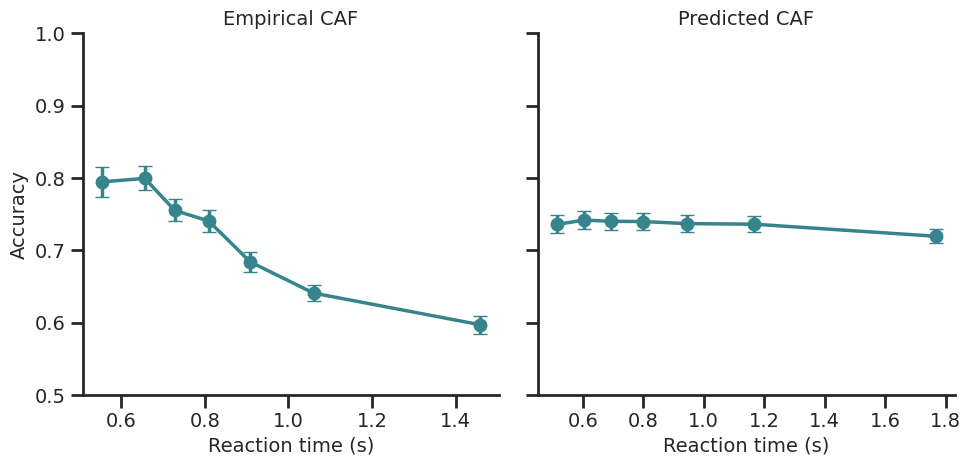

In [24]:
sns.set_theme(
    style="ticks",
    context="talk"
)

fontsize = 14
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Empirical CAF (left)
axes[0].errorbar(
    x=cond_acc["quantiles_rt_mean_rt"],
    y=cond_acc["mean"],
    yerr=cond_acc["std"] / np.sqrt(len(np.unique(data["subj"]))),
    fmt="o-",
    linewidth=2.5,
    capsize=5,
    color="#36848C"
)

axes[0].set_title("Empirical CAF", fontsize=fontsize)
axes[0].set_xlabel("Reaction time (s)", fontsize=fontsize)
axes[0].set_ylabel("Accuracy", fontsize=fontsize)
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(labelsize=fontsize, width=2.0)


# Predicted CAF (right)
axes[1].errorbar(
    x=cond_acc_predicted["quantiles_rt_mean_rt"],
    y=cond_acc_predicted["mean"],
    yerr=cond_acc_predicted["std"] / np.sqrt(len(np.unique(df_predicted["subj"]))),
    fmt="o-",
    linewidth=2.5,
    capsize=5,
    color="#36848C"
)

axes[1].set_title("Predicted CAF", fontsize=fontsize)
axes[1].set_xlabel("Reaction time (s)", fontsize=fontsize)
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(labelsize=fontsize, width=2.0)

# Styling
for ax in axes:
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(2.0)
    sns.despine(ax=ax)

plt.tight_layout()

fig.savefig(
    f"Figures/{dataset}_vanilla_ddm_caf_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

## Comparing empirical and predicted repetition matrix

### Empirical repetition matrix

In [25]:
# Create subset with two subsequent error trials only and calculate proportions
data_incorrect = data[(data["accuracy"] == 0) & (data["prev_accuracy"] == 0)]

cols = ["subj", "condition", "prev_condition"]

subj = np.arange(0, num_subjects)
condition = np.array(['fast_right', 'slow_right', 'fast_left', 'slow_left'])
prev_condition = np.array(['fast_right', 'slow_right', 'fast_left', 'slow_left'])

levels = [subj, condition, prev_condition]

full_index = pd.MultiIndex.from_product(levels, names=cols)

freq_incorrect = (
    data_incorrect
    .groupby(cols)
    .size()
    .reindex(full_index, fill_value=0)
    .reset_index(name="count"))

cond_prop_table_subject = freq_incorrect
cond_prop_table_subject["cond_prop"] = cond_prop_table_subject.groupby(["subj", "condition"])["count"].transform(lambda x: x / x.sum()).fillna(0)

cond_prop_table_subject.to_csv(f"Data/{dataset}_vanilla_ddm_empirical_repetition_matrix_subject.csv", index=False)

# Calculate the mean accuracy and standard error over all subjects
mean_sd_subjects = (
    cond_prop_table_subject.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

### Predicted repetition matrix

In [26]:
# Calculate the mean per subject per quantile over all repetitions
averaged_cond_props_subject_over_repetition = np.mean(cond_props_subject_over_repetition, axis=1)

# Use freq_incorrect for structure and replace cond_prop
cond_prop_table_subject_predicted = freq_incorrect_predicted
cond_prop_table_subject_predicted['cond_prop'] = averaged_cond_props_subject_over_repetition
cond_prop_table_subject_predicted = cond_prop_table_subject_predicted.drop(columns=["count"]) # remove count (are frequencies from only the last iteration)

cond_prop_table_subject_predicted.to_csv(f"Data/{dataset}_vanilla_ddm_predicted_repetition_matrix_subject.csv", index=False)

# Calculate the mean accuracy and standard error over all subjects
mean_sd_subjects_predicted = (
    cond_prop_table_subject_predicted.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

### Plotting

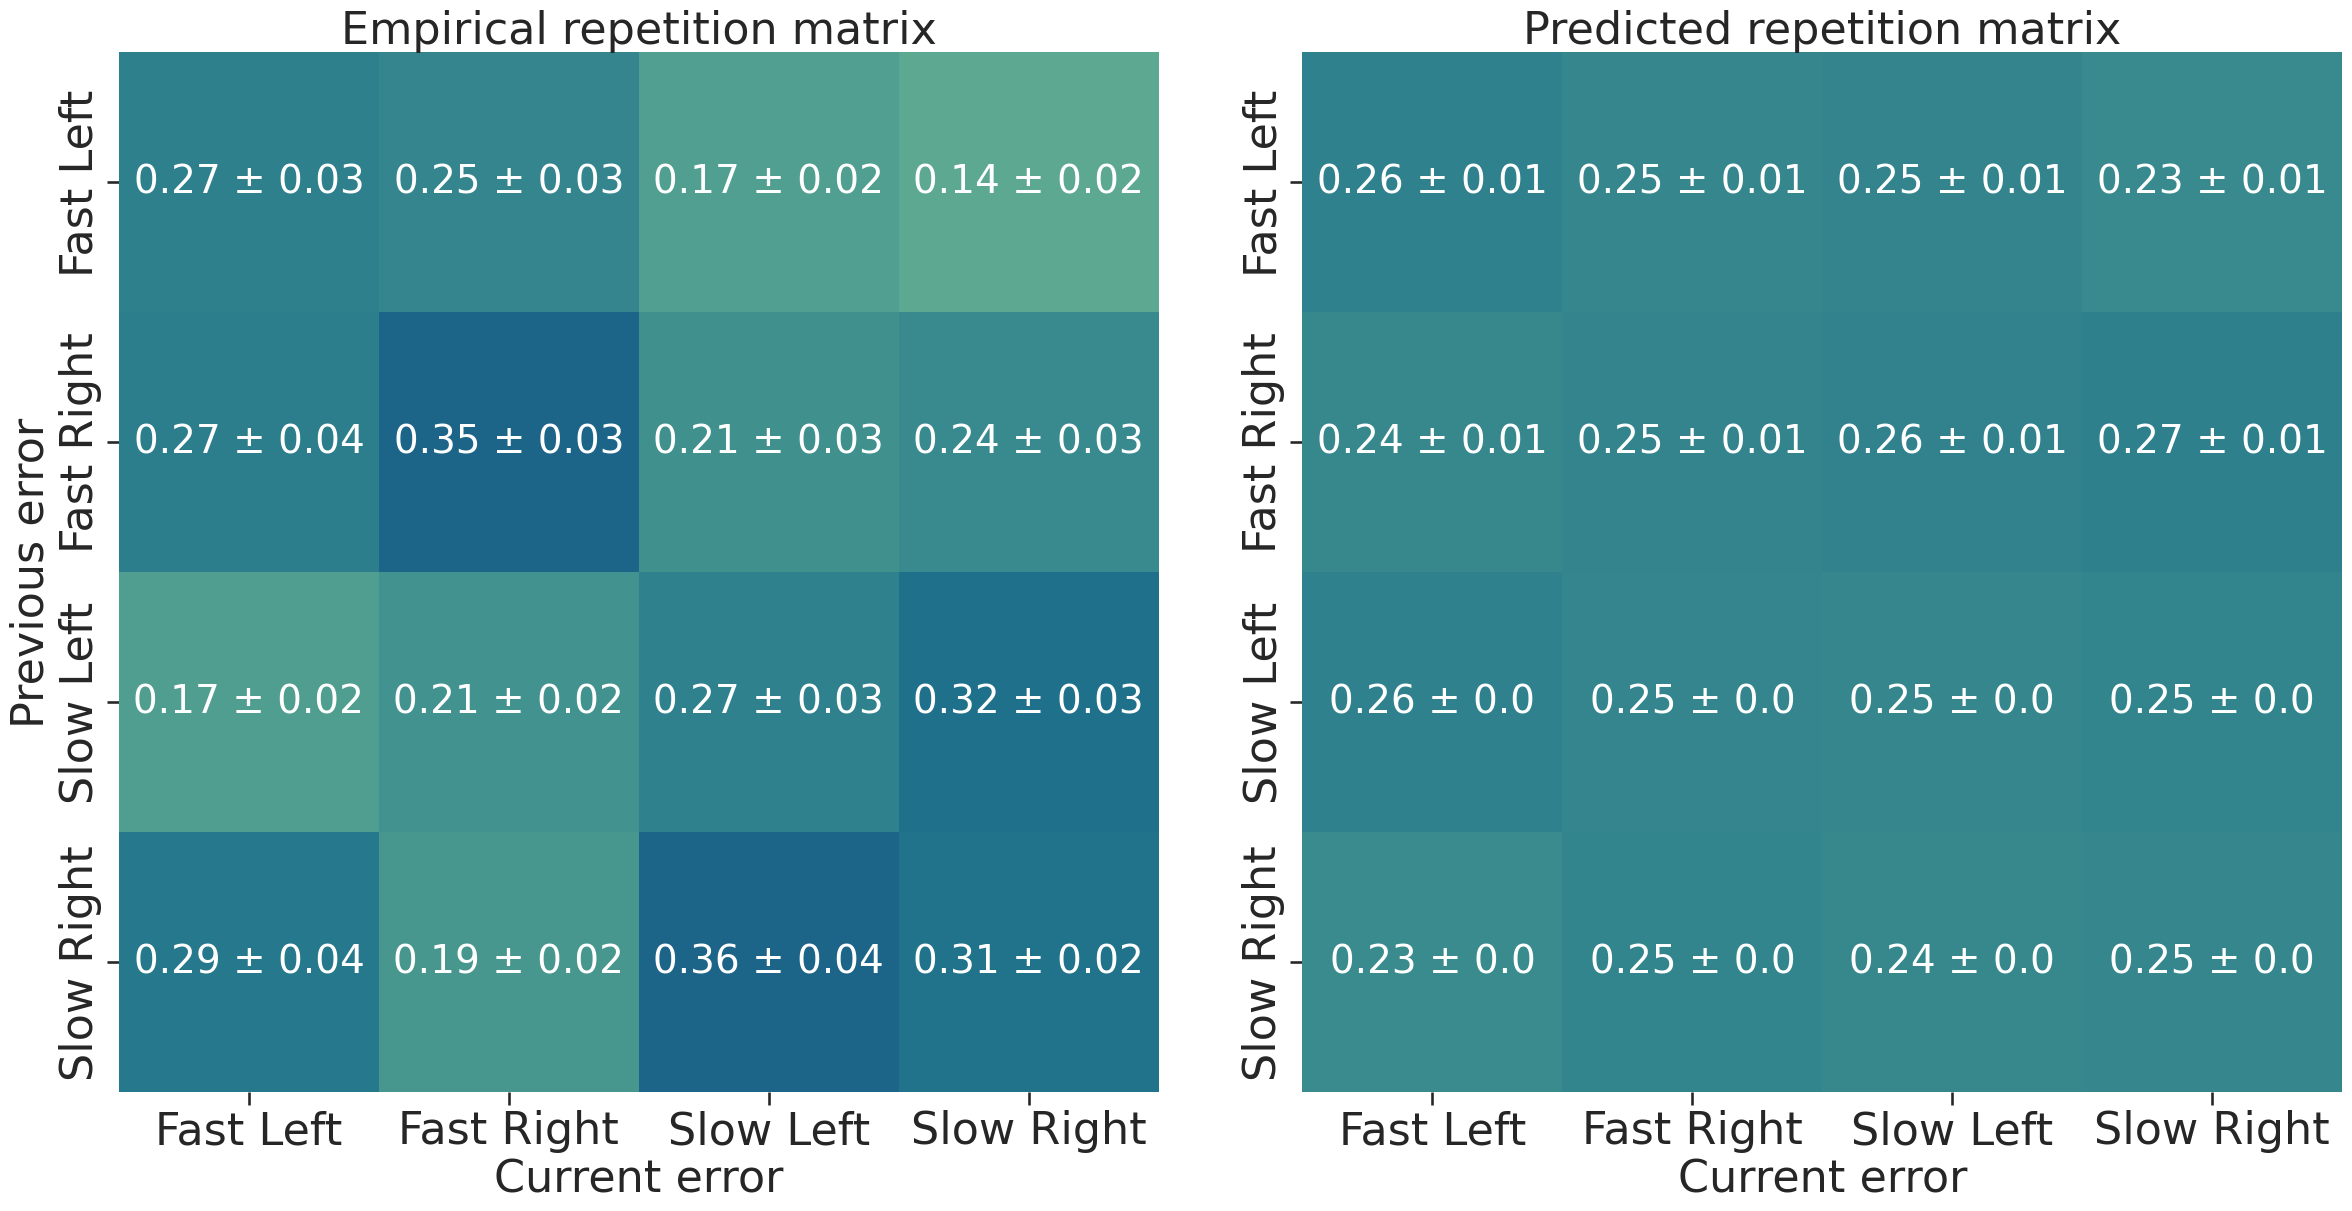

In [27]:
fontsize_heatmap = 32

# Empirical matrices
prop_table_mean = mean_sd_subjects.pivot(
    index="prev_condition",
    columns="condition",
    values="mean"
)

prop_table_std = mean_sd_subjects.pivot(
    index="prev_condition",
    columns="condition",
    values="std"
)

annot = (
    prop_table_mean.round(2).astype(str)
    + " ± "
    + (
        prop_table_std
        / np.sqrt(len(np.unique(data_incorrect["subj"])))
    ).round(2).astype(str)
)

# Predicted matrices
prop_table_mean_predicted = mean_sd_subjects_predicted.pivot(
    index="prev_condition",
    columns="condition",
    values="mean"
)

prop_table_std_predicted = mean_sd_subjects_predicted.pivot(
    index="prev_condition",
    columns="condition",
    values="std"
)

annot_predicted = (
    prop_table_mean_predicted.round(2).astype(str)
    + " ± "
    + (
        prop_table_std_predicted
        / np.sqrt(len(np.unique(data_incorrect_predicted["subj"])))
    ).round(2).astype(str)
)

condition_labels = [
    "Fast Left",
    "Fast Right",
    "Slow Left",
    "Slow Right"
]

# Create side-by-side plots
fig, axes = plt.subplots(
    1, 2,
    figsize=(24, 12),
    constrained_layout=True
)

# -------------------------
# Empirical
# -------------------------
sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin=0.0,
    vmax=0.5,
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "Empirical repetition matrix",
    fontsize=fontsize_heatmap
)
axes[0].set_xlabel(
    "Current error",
    fontsize=fontsize_heatmap
)
axes[0].set_ylabel(
    "Previous error",
    fontsize=fontsize_heatmap
)

axes[0].tick_params(axis="x", labelsize=fontsize_heatmap)
axes[0].tick_params(axis="y", labelsize=fontsize_heatmap)

for text in axes[0].texts:
    text.set_fontsize(28)

# -------------------------
# Predicted
# -------------------------
sns.heatmap(
    prop_table_mean_predicted,
    annot=annot_predicted,
    fmt="",
    cmap="crest",
    vmin=0.0,
    vmax=0.5,
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "Predicted repetition matrix",
    fontsize=fontsize_heatmap
)
axes[1].set_xlabel(
    "Current error",
    fontsize=fontsize_heatmap
)
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=fontsize_heatmap)
axes[1].tick_params(axis="y", labelsize=fontsize_heatmap)

for text in axes[1].texts:
    text.set_fontsize(28)

fig.savefig(
    f"Figures/{dataset}_vanilla_ddm_repetition_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)